#Part 1: Import Required Libraries

In [1]:
# tensorflow (as tf)
import tensorflow as tf
from tensorflow import keras
# keras layers: Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Keras Sequential
from tensorflow.keras.models import Sequential

# keras callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler

# keras regularizers: l2
from tensorflow.keras.regularizers import l2

# numpy (as np), matplotlib.pyplot (as plt), seaborn (as sns)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from sklearn.model_selection: train_test_split
from sklearn.model_selection import train_test_split

#from sklearn.metrics: classification_report, confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix

#Read the Data

In [2]:
import pandas as pd

# File paths
train_path = "/content/mitbih_test.csv"
test_path  = "/content//mitbih_train.csv"

# Files are 187 columns: 186 features + 1 label at the end. [web:28]
train_df = pd.read_csv(train_path, header=None)
test_df  = pd.read_csv(test_path, header=None)

train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Separate features and labels
X_train = train_df.iloc[:, :-1].values #leave the last columns because it is target.
y_train = train_df.iloc[:, -1].values

X_test  = test_df.iloc[:, :-1].values #leave the last columns because it is target.
y_test  = test_df.iloc[:, -1].values

In [4]:
from sklearn.preprocessing import LabelEncoder
#because its float values, the best way is to encoding it
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

#Build the model

In [6]:
def build_ann(input_dim, num_classes):
    model = Sequential()

    model.add(Dense(256, activation='relu', input_shape=(input_dim,), kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

##Train The Model.

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

ann_model = build_ann(X_train.shape[1], len(set(y_train)))

history = ann_model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8873 - loss: 0.8057 - val_accuracy: 0.9393 - val_loss: 0.5934
Epoch 2/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9245 - loss: 0.5784 - val_accuracy: 0.9365 - val_loss: 0.5019
Epoch 3/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9344 - loss: 0.4825 - val_accuracy: 0.9441 - val_loss: 0.4250
Epoch 4/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9383 - loss: 0.4150 - val_accuracy: 0.9543 - val_loss: 0.3551
Epoch 5/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9419 - loss: 0.3639 - val_accuracy: 0.9422 - val_loss: 0.3405
Epoch 6/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9445 - loss: 0.3290 - val_accuracy: 0.9559 - val_loss: 0.2904
Epoch 7/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9447 - loss: 0.3066 - val_accuracy: 0.9482 - val_loss: 0.2861
Epoch 8/100
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9447 - loss: 0.2884 - val_ac

In [9]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        48,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,889 (1.04 MB)

 Trainable params: 90,373 (353.02 KB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 180,748 (706.05 KB)

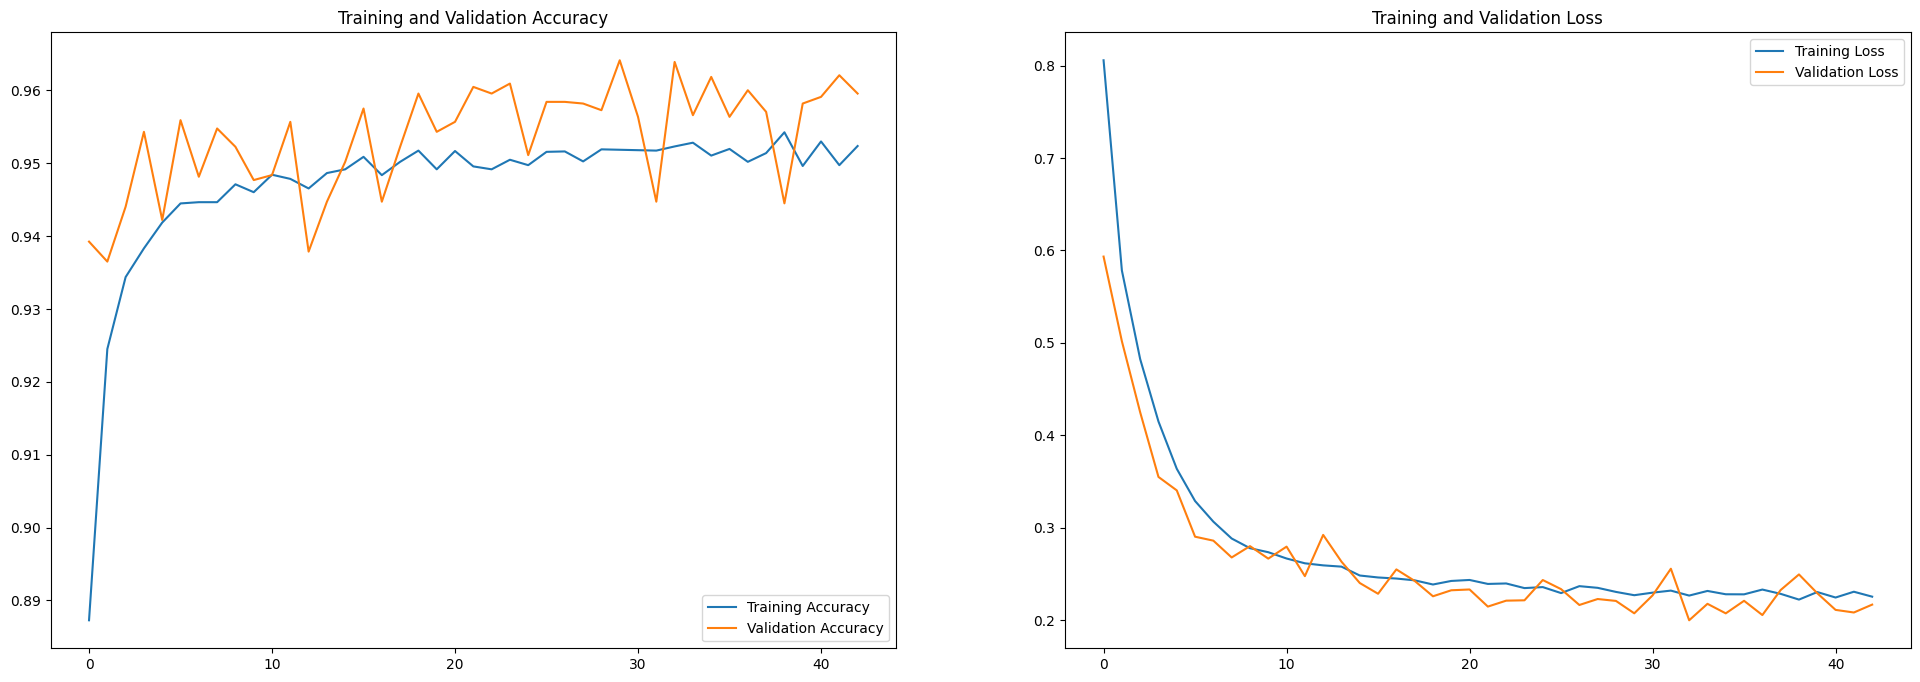

In [10]:
#plot the result
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(43)

plt.figure(figsize=(24, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

##Evaluate model

In [11]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Evaluate the model on the test set
loss, accuracy = ann_model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# Predictions
y_pred_probs = ann_model.predict(X_test)  # Get probabilities
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # Convert to class predictions

#Accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
print(f'Test Accuracy: {accuracy:.4f}')

#Recall
recall = recall_score(y_test, y_pred_classes, average='weighted')
print(f'Test Recall: {recall:.4f}')

#precision
precision = precision_score(y_test, y_pred_classes, average='weighted')
print(f'Test Precision: {precision:.4f}')

#f1-score1
f1 = f1_score(y_test, y_pred_classes, average='weighted')
print(f'Test F1-Score: {f1:.4f}')

Test Loss: 0.1997
Test Accuracy: 0.9632
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Test Accuracy: 0.9632
Test Recall: 0.9632
Test Precision: 0.9619
Test F1-Score: 0.9607



Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     72471
           1       0.93      0.54      0.68      2223
           2       0.89      0.85      0.87      5788
           3       0.78      0.41      0.54       641
           4       0.96      0.96      0.96      6431

    accuracy                           0.96     87554
   macro avg       0.91      0.75      0.81     87554
weighted avg       0.96      0.96      0.96     87554



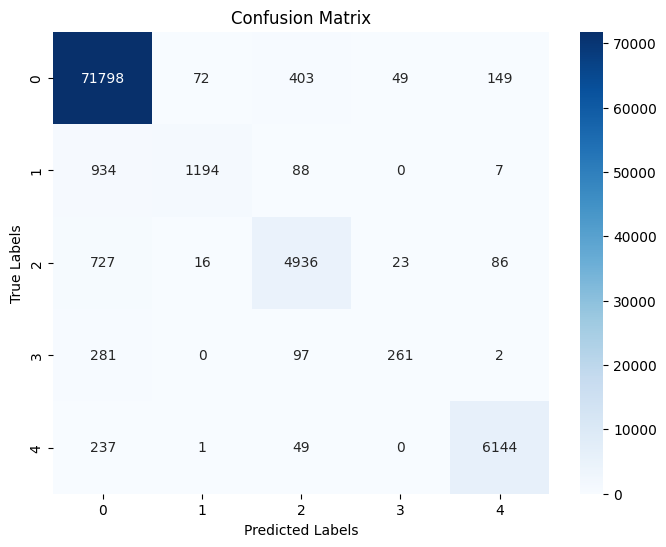

In [12]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=[str(i) for i in range(len(np.unique(y_test)))]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(len(np.unique(y_test)))], yticklabels=[str(i) for i in range(len(np.unique(y_test)))])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#Build the model with manually tuning

In [13]:
def build_model_lr(lr, input_dim, num_classes):
    # TODO:
    # Build the same model as baseline
    # but use Adam with a custom learning rate
    model = keras.Sequential([
        # Write your layers here
        keras.layers.Dense(256, activation="relu", input_shape=(input_dim,), kernel_regularizer=l2(0.001)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(learning_rate=lr)

    # Compile the model here
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
learning_rates = [0.1, 0.01, 0.001]

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")

    model = build_model_lr(lr, X_train.shape[1], len(set(y_train)))
    model.fit(X_train, y_train, epochs=3, batch_size=32, verbose=0)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print("Accuracy:", acc)


Training with learning rate = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.9389519691467285

Training with learning rate = 0.01
Accuracy: 0.9312881231307983

Training with learning rate = 0.001
Accuracy: 0.9357653856277466


#Save the Best Model

In [15]:
# TODO: Save the final model
ann_model.save("ann_model.keras")
